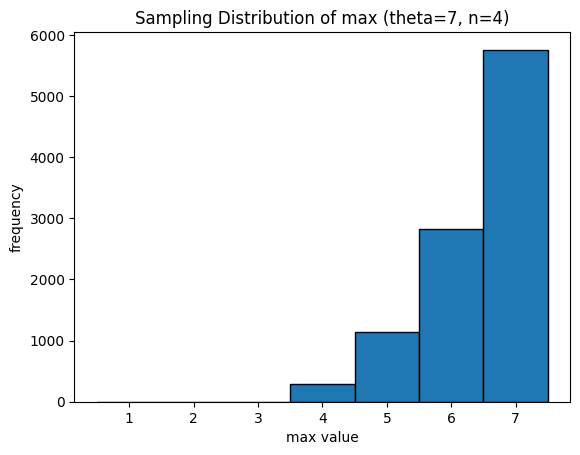

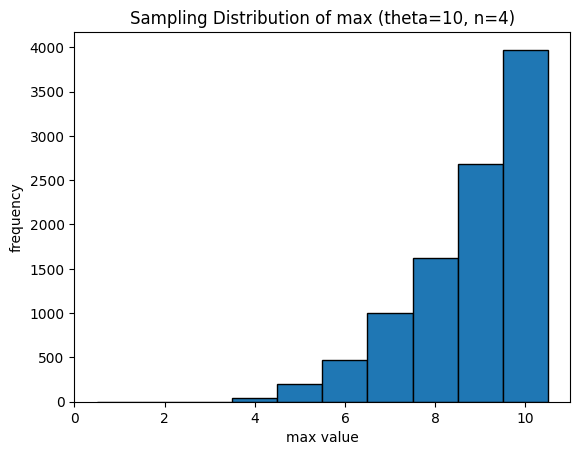

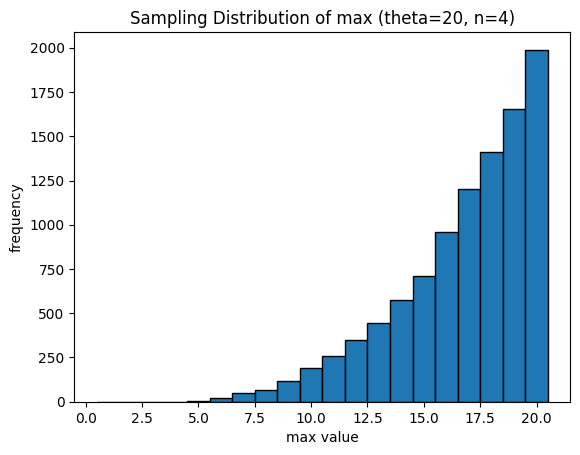

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_sampling_distribution(theta, n=4, sims=10000):
    max_vals = []
    population = np.arange(1, theta + 1)
    
    for _ in range(sims):
        sample = np.random.choice(population, size=n, replace=False)
        max_vals.append(np.max(sample))
    
    return np.array(max_vals)

thetas = [7, 10, 20]

for theta in thetas:
    max_vals = simulate_sampling_distribution(theta)

    plt.figure()
    plt.hist(max_vals, bins=range(1, theta+2), edgecolor='black', align='left')
    plt.title(f"Sampling Distribution of max (theta={theta}, n=4)")
    plt.xlabel("max value")
    plt.ylabel("frequency")
    plt.show()

In [29]:
def estimate_bias(theta, n=4, sims=10000):
    max_vals = simulate_sampling_distribution(theta, n, sims)
    mean_est = np.mean(max_vals)
    bias_sim = mean_est - theta
    
    bias_theory = (n - theta) / (n + 1)
    
    return mean_est, bias_sim, bias_theory

for theta in [7, 10, 20]:
    mean_est, bias_sim, bias_theory = estimate_bias(theta)
    
    print(f"Theta={theta}")
    print(f"  Simulated E[theta_hat] ≈ {mean_est:.3f}")
    print(f"  Simulated Bias ≈ {bias_sim:.3f}")
    print(f"  Theoretical Bias = {bias_theory:.3f}")
    print()

Theta=7
  Simulated E[theta_hat] ≈ 6.399
  Simulated Bias ≈ -0.601
  Theoretical Bias = -0.600

Theta=10
  Simulated E[theta_hat] ≈ 8.811
  Simulated Bias ≈ -1.189
  Theoretical Bias = -1.200

Theta=20
  Simulated E[theta_hat] ≈ 16.787
  Simulated Bias ≈ -3.213
  Theoretical Bias = -3.200



In [30]:
theta = 55
sample_sizes = [1, 2, 5, 10, 20, 30, 50]

results = []

for n in sample_sizes:
    max_vals = simulate_sampling_distribution(theta, n)
    mean_est = np.mean(max_vals)
    
    bias_sim = mean_est - theta
    bias_theory = (n - theta) / (n + 1)
    
    results.append((n, bias_sim, bias_theory))

for n, bias_sim, bias_theory in results:
    print(f"n={n:2d} | Sim Bias ≈ {bias_sim:.3f} | Theory Bias = {bias_theory:.3f}")

n= 1 | Sim Bias ≈ -26.702 | Theory Bias = -27.000
n= 2 | Sim Bias ≈ -17.691 | Theory Bias = -17.667
n= 5 | Sim Bias ≈ -8.389 | Theory Bias = -8.333
n=10 | Sim Bias ≈ -4.049 | Theory Bias = -4.091
n=20 | Sim Bias ≈ -1.673 | Theory Bias = -1.667
n=30 | Sim Bias ≈ -0.796 | Theory Bias = -0.806
n=50 | Sim Bias ≈ -0.099 | Theory Bias = -0.098
